# Installations and Imports

In [1]:
pip install opencv-python

In [2]:
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import shutil
from zipfile import ZipFile
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import numpy as np
from collections import Counter
from sklearn.model_selection import GridSearchCV

# Crop Type Classifier

## Data Exploration

In [3]:
# Unzip the training data
with ZipFile("train.zip", 'r') as zObject:
    zObject.extractall(
        path="data")

# Unzip the testing data
with ZipFile("test.zip", 'r') as zObject:
    zObject.extractall(
        path="data")

In [4]:
# Show examples training and testing images in array format

img_testy = []

img = cv2.imread('data/train/Apple leaf/20130519yellowingappleleaves.jpg') # Reads in BGR format
img_resized = cv2.resize(img, (128, 128)) # Resize to a consistant size
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY) # Convert the image to gray
img_testy.append(img_gray) # Add the edited image to the array

img = cv2.imread('data/test/Apple leaf/20180511_091133-24l1vhg-e1526047988236.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread("/content/data/train/Apple Scab Leaf/01Apple-scab-2-Venturia-inaequalis.jpg")
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Apple Scab Leaf/052609%20Hartman%20Crabapple%20scab%20single%20leaf.JPG.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img_testy # Print out the pixel values of the four example images

[array([[101, 130, 149, ..., 141, 144, 115],
        [142, 158, 151, ..., 151, 151,  99],
        [149, 153, 149, ..., 150, 131, 101],
        ...,
        [ 75,  90,  62, ..., 125, 112, 112],
        [ 64,  78,  70, ..., 119, 118, 119],
        [ 42,  46,  67, ..., 117, 118, 122]], dtype=uint8),
 array([[ 99, 107, 145, ..., 131, 120, 128],
        [109, 116, 162, ..., 152, 128, 123],
        [121, 138, 144, ..., 168, 156, 139],
        ...,
        [102, 125, 120, ...,  84,  91, 104],
        [105, 120, 119, ..., 108, 113, 116],
        [115, 121, 132, ...,  93, 102,  91]], dtype=uint8),
 array([[121, 143, 156, ..., 117,  94,  61],
        [118, 136, 144, ...,  84,  54,  52],
        [140, 144, 165, ...,  51,  48,  49],
        ...,
        [151, 125, 147, ..., 170, 171, 197],
        [148, 127, 156, ..., 164, 165, 192],
        [157, 155, 159, ..., 155, 166, 181]], dtype=uint8),
 array([[162, 162, 161, ...,  81,  78,  77],
        [161, 162, 161, ...,  76,  82,  78],
        [165, 16

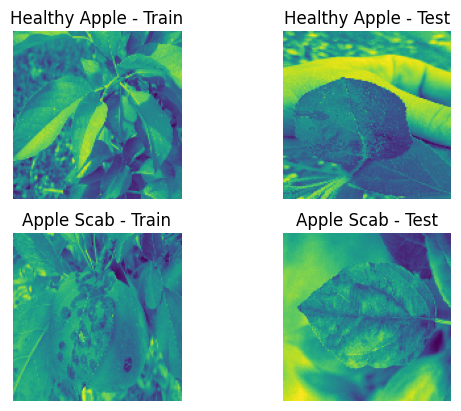

In [5]:
# Add the first image to the figure (top-left position)
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, first position
plt.imshow(img_testy[0])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Apple - Train")

# Add the second image to the figure (top-right position)
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, second position
plt.imshow(img_testy[1])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Apple - Test")

# Add the third image to the figure (bottom-left position)
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, third position
plt.imshow(img_testy[2])
plt.axis('off')  # Hide the axis labels
plt.title("Apple Scab - Train")

# Add the fourth image to the figure (bottom-right position)
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, fourth position
plt.imshow(img_testy[3])
plt.axis('off')  # Hide the axis labels
plt.title("Apple Scab - Test")

plt.show()

## Prepare Data

In [26]:
# function to extract HOG features given the file path of an image
def load_and_extract_features(directory):
    X = []
    y = []
    for label in os.listdir(directory): #loops through each folder in the given directory
        label_dir = os.path.join(directory, label)
        label_name = label.split()[0]
        for filename in os.listdir(label_dir): # loop through each file in the selected folder
            image_path = os.path.join(label_dir, filename)
            # Load image using OpenCV
            img = cv2.imread(image_path)
            # Resize image to (128, 128)
            img_resized = cv2.resize(img, (128, 128))
            # Convert image to grayscale
            img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            # Calculate HOG features
            hog_features = extract_hog_features(img_gray)
            X.append(hog_features)
            y.append(label_name)
    return X, y

In [27]:
# function to calculate HOG features
def extract_hog_features(image):
    hog_features = hog(image, orientations=9, pixels_per_cell=(8, 8),
    cells_per_block=(2, 2), visualize=False)
    return hog_features

In [28]:
# Create the training features and labels
train_X, train_y = load_and_extract_features('data/train')

In [29]:
# Exmaple training element's features
train_X[0]

array([0.27587933, 0.27587933, 0.11424659, ..., 0.0201436 , 0.13353793,
       0.03054783])

In [30]:
# Example training element's label
train_y[0]

'Tomato'

In [31]:
# Number of training elements
len(train_X)

671

In [32]:
print(np.unique(train_y))

['Tomato']


In [33]:
print(Counter(train_y))

Counter({'Tomato': 671})


In [34]:
test_X, test_y = load_and_extract_features('data/test')

In [35]:
test_X[0]

array([0.23228603, 0.12581255, 0.23875737, ..., 0.14114763, 0.14243318,
       0.23041494])

In [36]:
test_y[0]

'Tomato'

In [37]:
len(test_X)

69

In [38]:
print(np.unique(test_y))

['Tomato']


In [39]:
print(Counter(test_y))

Counter({'Tomato': 69})


## Train and Test Model

In [40]:
rf_classifier = RandomForestClassifier(n_estimators=500, max_features="sqrt", criterion='entropy', max_depth=7)
rf_classifier.fit(train_X, train_y)

RandomForestClassifier(criterion='entropy', max_depth=7, n_estimators=500)

In [41]:
y_pred = rf_classifier.predict(test_X)
rf_accuracy = accuracy_score(test_y, y_pred)

print(classification_report(y_pred, test_y))

              precision    recall  f1-score   support

      Tomato       1.00      1.00      1.00        69

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [ ]:
print(y_pred)

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [500, 1000],
    'max_features': ['sqrt'],
    'max_depth': [5, 7, 8],
    'criterion': ['gini', 'entropy']
}

In [ ]:
grid_search = GridSearchCV(RandomForestClassifier(),
                           param_grid=param_grid)
grid_search.fit(train_X, train_y)
print(grid_search.best_estimator_)

# Tomato Disease Classifier

In [ ]:
with ZipFile("train_tomato.zip", 'r') as zObject:
    zObject.extractall(
        path="data_tomato")

with ZipFile("test_tomato.zip", 'r') as zObject:
    zObject.extractall(
        path="data_tomato")

## Data Exploration

In [ ]:
#show an example training image in array format

img_testy = []

img = cv2.imread('/content/data/train/Tomato leaf/003.JPG.jpg') # Reads in BGR format
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Tomato leaf/1684.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread("/content/data/train/Tomato Early blight leaf/100_46341.jpg")
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img = cv2.imread('/content/data/test/Tomato Early blight leaf/100983448.jpg')
img_resized = cv2.resize(img, (128, 128))
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_testy.append(img_gray)

img_testy

In [ ]:
# Add the first image to the figure (top-left position)
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, first position
plt.imshow(img_testy[0])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Tomato - Train")

# Add the second image to the figure (top-right position)
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, second position
plt.imshow(img_testy[1])
plt.axis('off')  # Hide the axis labels
plt.title("Healthy Tomato - Test")

# Add the third image to the figure (bottom-left position)
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, third position
plt.imshow(img_testy[2])
plt.axis('off')  # Hide the axis labels
plt.title("Early Blight Tomato - Train")
# Add the fourth image to the figure (bottom-right position)
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, fourth position
plt.imshow(img_testy[3])
plt.axis('off')  # Hide the axis labels
plt.title("Early Blight Tomato - Test")

#plt.imshow(img_gray)
plt.show()

## Prepare Data

In [ ]:
# function to extract HOG features and label given the file path of an image
#TO-DO: change this code to extract disease type
def load_and_extract_disease_features(directory):
    X = []
    y = []
    for label in os.listdir(directory):
        label_dir = os.path.join(directory, label)
        label_name = label.split()[0]
        for filename in os.listdir(label_dir):
            image_path = os.path.join(label_dir, filename)
            # Load image using OpenCV
            img = cv2.imread(image_path)
            # Resize image to (128, 128)
            img_resized = cv2.resize(img, (128, 128))
            # Convert image to grayscale
            img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
            # Calculate HOG features
            hog_features = extract_hog_features(img_gray)
            X.append(hog_features)
            y.append(label_name)
    return X, y

Use the HOG features function that was defined earlier.